# LES long-range model: accuracy and numerical stability

Analysis of the matched comparison between an ordinary DeePMD model and the two LES (`hybrid_ener`) variants on the DeepMD-kit-FastLearn water dataset.
Three arms, two replicates (different network and training seeds), 10,000 steps each.
All figures read the run artifacts under `extended/`; nothing here retrains anything.

- `ordinary` - standard DeePMD, no long-range term.
- `hybrid_q` - LES with learnable latent charges.
- `hybrid_fixed` - LES with fixed atomic charges (plus a learned correction).


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "grid.color": "#d8d7d2", "grid.linewidth": 0.6,
    "legend.frameon": False, "font.size": 10,
})

MODELS = ["ordinary", "hybrid_q", "hybrid_fixed"]
SEEDS = ["A", "B"]
# Categorical slots 1-3 of the validated palette; all-pairs safe in light and
# dark. Replicate is carried by line style, so identity is never color-alone.
COLOR = {"ordinary": "#2a78d6", "hybrid_q": "#eb6834", "hybrid_fixed": "#1baf7a"}
LS = {"A": "-", "B": "--"}

HERE = Path.cwd()
EXT = HERE / "extended"
LC_COLS = ["step", "rmse_val", "rmse_trn", "rmse_e_val", "rmse_e_trn",
           "rmse_f_val", "rmse_f_trn", "lr"]


def tag_of(model, seed):
    return f"{model}_s{seed}"


def read_lcurve(model, seed):
    t = tag_of(model, seed)
    return pd.read_csv(EXT / f"run_{t}" / f"lcurve_{t}.out",
                       sep=r"\s+", skiprows=2, names=LC_COLS)


curves = {(m, s): read_lcurve(m, s) for m in MODELS for s in SEEDS}
print("learning curves:", len(curves),
      "| rows each:", len(next(iter(curves.values()))))

learning curves: 6 | rows each: 101


## Learning curves

Validation RMSE as logged during training.
Note the vertical scale is logarithmic: late in training the energy curves are jagged rather than smooth, which the next sections take apart.

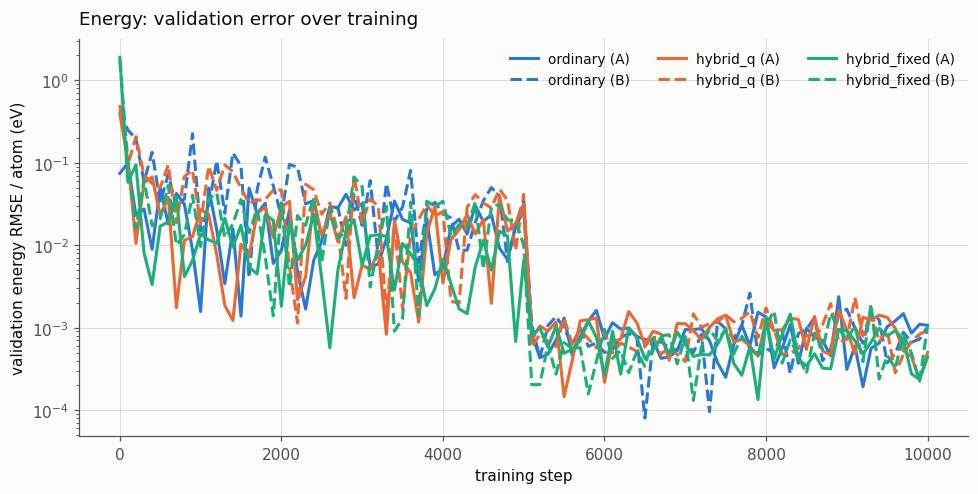

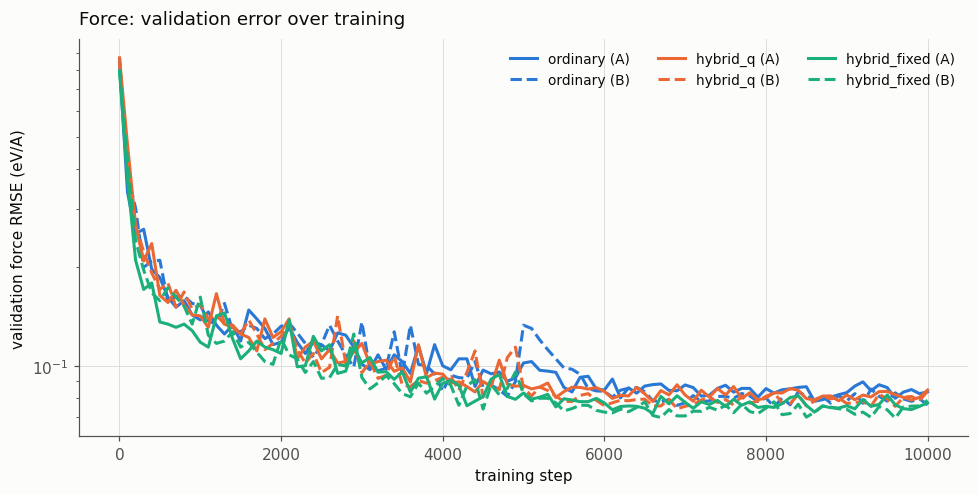

In [2]:
def plot_lcurve(col, ylabel, title):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    for m in MODELS:
        for s in SEEDS:
            d = curves[(m, s)]
            ax.plot(d.step, d[col], color=COLOR[m], ls=LS[s], lw=2,
                    label=f"{m} ({s})")
    ax.set_yscale("log")
    ax.set_xlabel("training step")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontsize=12, pad=10)
    ax.grid(True, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(ncol=3, fontsize=9)
    fig.tight_layout()
    plt.show()


plot_lcurve("rmse_e_val", "validation energy RMSE / atom (eV)",
            "Energy: validation error over training")
plot_lcurve("rmse_f_val", "validation force RMSE (eV/A)",
            "Force: validation error over training")

## Why the logged curve is jagged

The logged validation value is not an average over the validation set.
`training.validation_data` uses `batch_size: 1` with `numb_btch: 3`, and the training loop draws only those 3 batches at each display step (`deepmd/pt/train/training.py`, `log_loss_valid`).
So every logged point is the RMSE over **3 randomly drawn frames out of 80**, drawn from the model as it stood at that step.

That subsampling has two consequences, and they have to be kept apart:

1. A single 3-frame draw is a wide, right-skewed estimate. Simulating draws from one checkpoint's per-frame errors gives a 5th-to-95th percentile span of roughly 2x to 5x, but a median only 2% to 12% below that checkpoint's true full-set value. So the logged curve is noisy without being systematically far off.
2. Different logged points come from **different checkpoints**. Lumping a window of them into one cloud and comparing that cloud against one checkpoint's exact value is invalid, because over the same window the model's own error can move by more than the sampling spread.

The figure below keeps the two apart, one panel per run: dots are the logged draws, the black line joins the exact full-set values of the saved checkpoints from step 6000 to 10000.
Read the dots against the segment of black line at the same x, never against the line as a whole.
`hybrid_fixed` replicate B is the clearest case: its logged values sit around 7e-4, while the step-10000 exact value is 1.55e-3.
That gap is the model moving, not the sampling, because 3-frame sampling from that same checkpoint has a median of 1.50e-3, only 3% below its exact value.

Each individual logged value does check out against its own checkpoint.
At step 8000 `hybrid_fixed` B logged 1.100e-3 against a sampling distribution with median 9.24e-4, and at step 9000 it logged 7.080e-4 against a median of 6.21e-4.
Both are ordinary draws. It is only the lumped cloud that misleads.

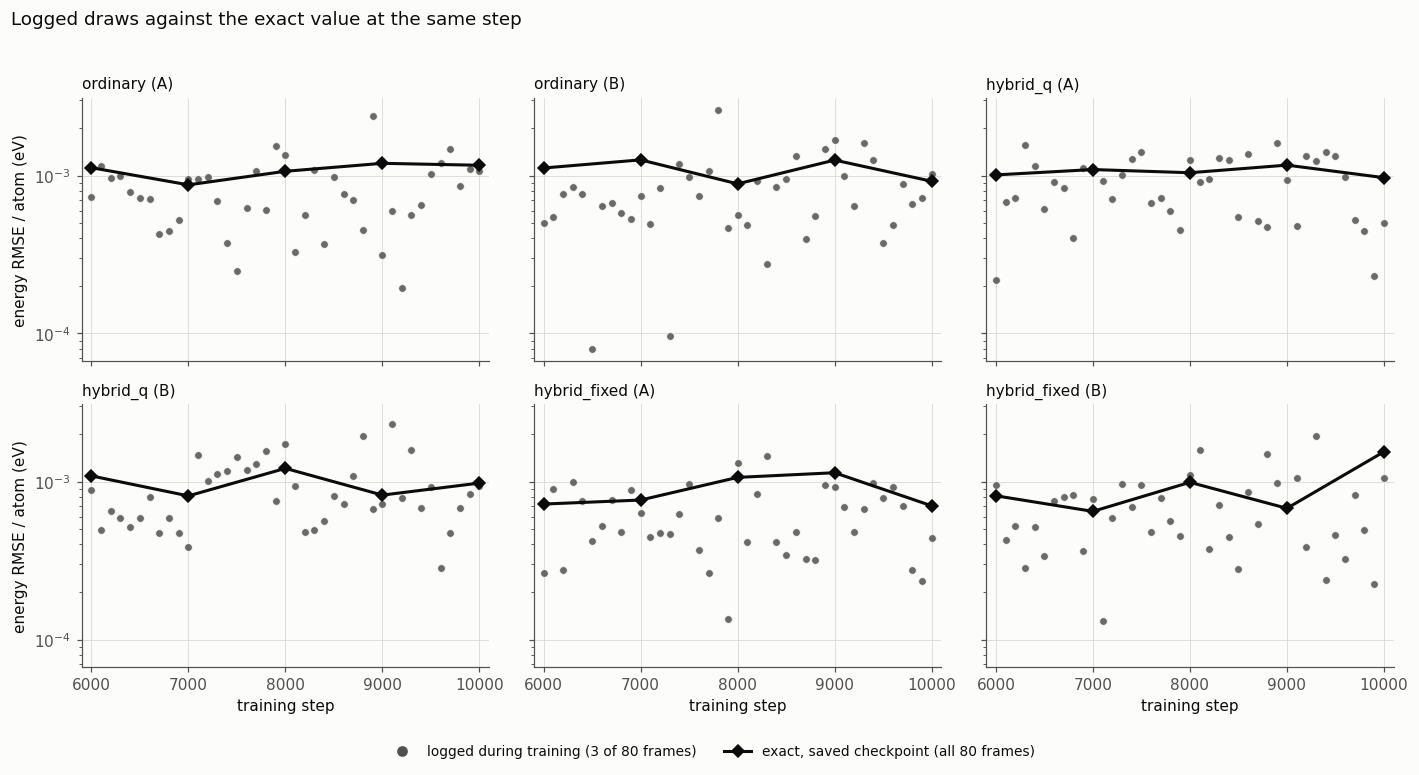

In [3]:
sweep_path = HERE / "sweep_valid.tsv"
sweep = pd.read_csv(sweep_path, sep="\t") if sweep_path.exists() else pd.DataFrame()

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, (m, s) in zip(axes.ravel(), [(m, s) for m in MODELS for s in SEEDS]):
    d = curves[(m, s)]
    t = d.loc[d.step.between(6000, 10000)]
    ax.scatter(t.step, t.rmse_e_val, s=26, color="#52514e", alpha=0.85,
               edgecolor=SURFACE, linewidth=0.6, zorder=3)
    if len(sweep):
        ex = sweep[(sweep.model == m) & (sweep.rep == s)].sort_values("step")
        ax.plot(ex.step, ex.rmse_e_peratom, color=INK, lw=2, marker="D", ms=6,
                zorder=4)
    ax.set_yscale("log")
    ax.set_xlim(5900, 10100)
    ax.set_title(f"{m} ({s})", loc="left", fontsize=10, pad=6)
    ax.grid(True, alpha=0.9)
    ax.set_axisbelow(True)
for ax in axes[1]:
    ax.set_xlabel("training step")
for ax in axes[:, 0]:
    ax.set_ylabel("energy RMSE / atom (eV)")
fig.legend(handles=[
    Line2D([], [], ls="none", marker="o", ms=6, color="#52514e",
           label="logged during training (3 of 80 frames)"),
    Line2D([], [], color=INK, lw=2, marker="D", ms=6,
           label="exact, saved checkpoint (all 80 frames)"),
], loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.008))
fig.suptitle("Logged draws against the exact value at the same step",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.045, 1, 0.96))
plt.show()

## Exact values per checkpoint

Evaluating each saved checkpoint over all 80 validation frames (no subsampling) removes the sampling noise.
What remains is the model's own movement: the energy error swings by 1.1x to 2.3x across the late checkpoints **for every arm, including the ordinary one**, while the force error falls monotonically and varies by at most 1.1%.
That is the key stability finding: single-checkpoint energy numbers, and single logged points, are both unreliable, so the comparison has to average over several late checkpoints.

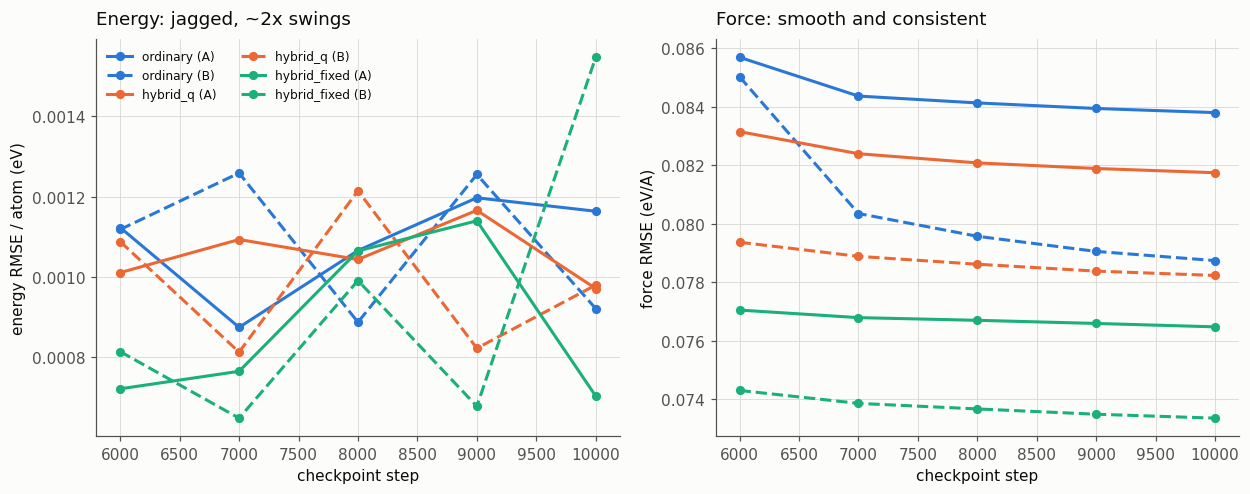

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True)
if len(sweep):
    for m in MODELS:
        for s in SEEDS:
            d = sweep[(sweep.model == m) & (sweep.rep == s)].sort_values("step")
            lbl = f"{m} ({s})"
            axes[0].plot(d.step, d.rmse_e_peratom, color=COLOR[m], ls=LS[s],
                         lw=2, marker="o", ms=5, label=lbl)
            axes[1].plot(d.step, d.rmse_f, color=COLOR[m], ls=LS[s],
                         lw=2, marker="o", ms=5)
    axes[0].set_ylabel("energy RMSE / atom (eV)")
    axes[1].set_ylabel("force RMSE (eV/A)")
    axes[1].set_title("Force: smooth and consistent", loc="left", fontsize=12, pad=10)
    axes[0].set_title("Energy: jagged, ~2x swings", loc="left", fontsize=12, pad=10)
    for a in axes:
        a.set_xlabel("checkpoint step")
        a.grid(True, alpha=0.9)
        a.set_axisbelow(True)
    axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## What the metric is made of: bias and spread

The exact energy number is the L2 norm of one per-frame value, so it pays for two unrelated things at once:

`rmse_e^2 = mean(e)^2 + var(e) = bias^2 + spread^2`, with `e_i = (E_pred,i - E_label,i) / natoms`.

That is the sample form of the bias-variance split. The usual ML statement is that expected squared error separates into a bias term (the model is systematically off) and a variance term (the model is sensitive to the particular sample); here the "sample" is the fixed set of 80 validation frames, so `bias` is a per-frame constant the checkpoint is off by and `spread` is how much the individual frames scatter around it. A single scalar hides the difference, and the two move for different reasons, so it is worth reading them apart.

For an energy model the bias term has a concrete meaning. Forces are the gradient of the energy, so a constant added to a frame's energy cannot change `rmse_f`; and the absolute energy zero is fixed only by the training data's mean energy, not by any physical interaction. A drift of the energy zero is therefore exactly the kind of change that moves `rmse_e` while leaving `rmse_f` untouched - which is the pattern the stability section above reports.

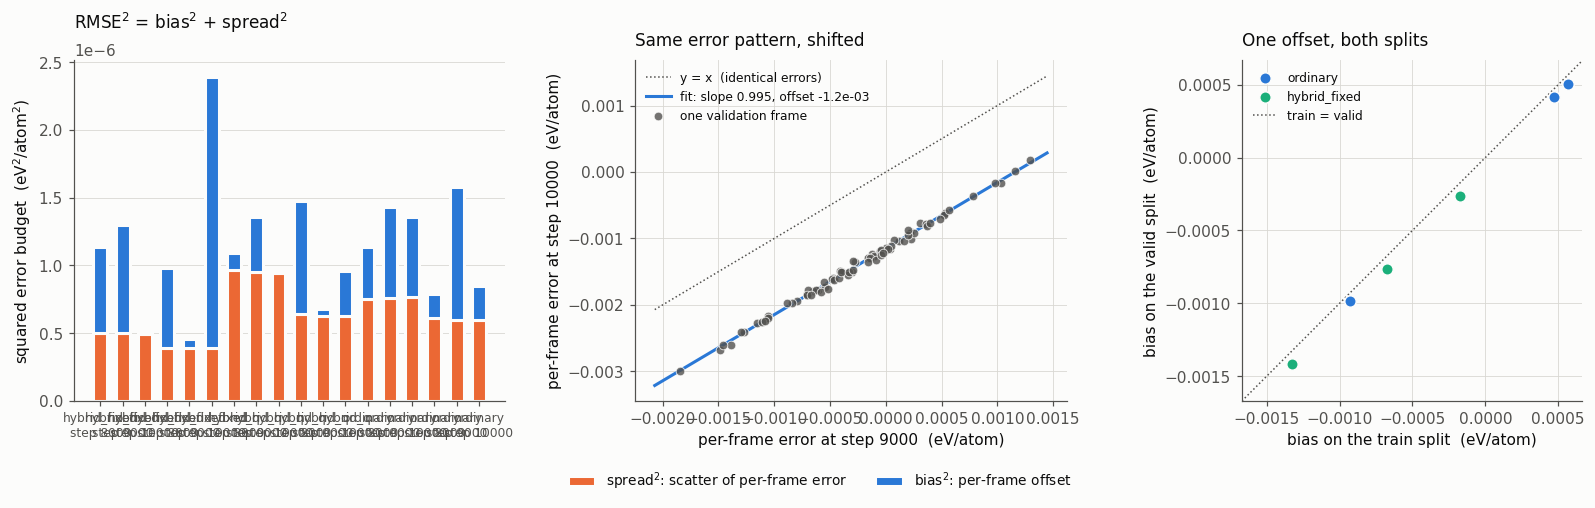

,model,rep,step,rmse,bias,spread
0,hybrid_fixed,A,8000,0.001065,-0.000795,0.000708
1,hybrid_fixed,A,9000,0.001140,-0.000895,0.000706
2,hybrid_fixed,A,10000,0.000704,0.000011,0.000703
3,hybrid_fixed,B,8000,0.000991,-0.000767,0.000627
4,hybrid_fixed,B,9000,0.000678,-0.000265,0.000624
5,hybrid_fixed,B,10000,0.001547,-0.001416,0.000622
6,hybrid_q,A,8000,0.001044,-0.000348,0.000984
7,hybrid_q,A,9000,0.001166,-0.000637,0.000976
8,hybrid_q,A,10000,0.000971,-0.000015,0.000971
9,hybrid_q,B,8000,0.001215,-0.000912,0.000802


In [5]:
def _dec(path):
    d = pd.read_csv(path, sep="\t") if Path(path).exists() else pd.DataFrame()
    if not len(d):
        return d
    grp = d.groupby(["run", "model", "rep", "step"])["peratom_de"]
    o = grp.agg(bias="mean", rmse=lambda s: np.sqrt((s ** 2).mean())).reset_index()
    o["spread"] = np.sqrt(o.rmse ** 2 - o.bias ** 2)
    return o.sort_values(["run", "step"]).reset_index(drop=True)


vpath, tpath = HERE / "bias_frames_valid.tsv", HERE / "bias_frames_train.tsv"
dv, dt = _dec(vpath), _dec(tpath)
raw_v = pd.read_csv(vpath, sep="\t") if Path(vpath).exists() else pd.DataFrame()

if len(dv):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    ax = axes[0]
    x = np.arange(len(dv))
    lab = [f"{r.replace('run_', '').rsplit('_s', 1)[0]}\nstep {int(s)}"
           for r, s in zip(dv.run, dv.step)]
    ax.bar(x, dv.spread ** 2, width=0.62, color="#eb6834", edgecolor=SURFACE,
           linewidth=2, label="spread$^2$: scatter of per-frame error")
    ax.bar(x, dv.bias ** 2, width=0.62, bottom=dv.spread ** 2,
           color="#2a78d6", edgecolor=SURFACE, linewidth=2,
           label="bias$^2$: per-frame offset")
    ax.set_xticks(x)
    ax.set_xticklabels(lab, fontsize=8)
    ax.set_ylabel("squared error budget  (eV$^2$/atom$^2$)")
    ax.set_title("RMSE$^2$ = bias$^2$ + spread$^2$", loc="left", fontsize=11, pad=10)
    ax.grid(True, axis="y", alpha=0.9)
    ax.set_axisbelow(True)
    h0, l0 = ax.get_legend_handles_labels()

    ax = axes[1]
    hf = raw_v[raw_v.run == "run_hybrid_fixed_sB"]
    wide = hf.pivot_table(index="frame", columns="step", values="peratom_de")
    a, b = wide[9000].values, wide[10000].values
    sl, ic = np.polyfit(a, b, 1)
    lo, hi = a.min() * 1.12, a.max() * 1.12
    ax.plot([lo, hi], [lo, hi], color=INK2, lw=1, ls=":",
            label="y = x  (identical errors)")
    ax.plot([lo, hi], sl * np.array([lo, hi]) + ic, color="#2a78d6", lw=2,
            label=f"fit: slope {sl:.3f}, offset {ic:+.1e}")
    ax.scatter(a, b, s=32, color="#52514e", alpha=0.8, edgecolor=SURFACE,
               linewidth=0.6, zorder=3, label="one validation frame")
    ax.set_xlabel("per-frame error at step 9000  (eV/atom)")
    ax.set_ylabel("per-frame error at step 10000  (eV/atom)")
    ax.set_title("Same error pattern, shifted", loc="left", fontsize=11, pad=10)
    ax.grid(True, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, loc="upper left")

    ax = axes[2]
    if len(dt):
        both = dt.merge(dv, on=["run", "model", "rep", "step"],
                        suffixes=("_trn", "_val"))
        for mdl in ["ordinary", "hybrid_fixed"]:
            s = both[both.model == mdl]
            ax.scatter(s.bias_trn, s.bias_val, s=56, color=COLOR[mdl],
                       edgecolor=SURFACE, linewidth=1.0, zorder=3, label=mdl)
        lo = both[["bias_trn", "bias_val"]].values.min() * 1.18
        hi = both[["bias_trn", "bias_val"]].values.max() * 1.18
        ax.plot([lo, hi], [lo, hi], color=INK2, lw=1, ls=":", label="train = valid")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("bias on the train split  (eV/atom)")
        ax.set_ylabel("bias on the valid split  (eV/atom)")
        ax.set_title("One offset, both splits", loc="left", fontsize=11, pad=10)
        ax.grid(True, alpha=0.9)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8, loc="upper left")

    fig.legend(h0, l0, loc="lower center", ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()

    display(dv[["model", "rep", "step", "rmse", "bias", "spread"]].round(8))

The left panel splits each checkpoint's squared error into the scatter of its per-frame errors (orange, near-constant) and the per-frame offset (blue, which moves).
The middle panel regresses one checkpoint's per-frame errors on another's: slope `0.995` against a residual 15x smaller than the signal means the two checkpoints make the *same* per-frame errors plus a constant vertical shift.
The right panel is the one that rules out a data cause. Re-measuring the *train* split at the same checkpoints puts every point on the `train = valid` line, the two splits differing only by a fixed ~1e-4 mean-energy mismatch.
So the offset is the model's energy zero, carried identically on both splits; a physical change to the energy surface would instead alter the slope or the spread.

## Arm comparison, averaged over late checkpoints

Bars are the mean over checkpoints 8000-10000; the dots and whisker show the individual checkpoints and their min-max spread, so the instability above stays visible.
The force panel is the trustworthy one: `hybrid_fixed` is ahead of `ordinary` in both replicates, and the two replicates behave the same way.
The energy panel is not: `hybrid_fixed` is clearly ahead in replicate A but its spread straddles `ordinary` in replicate B, so no reliable energy ranking survives.

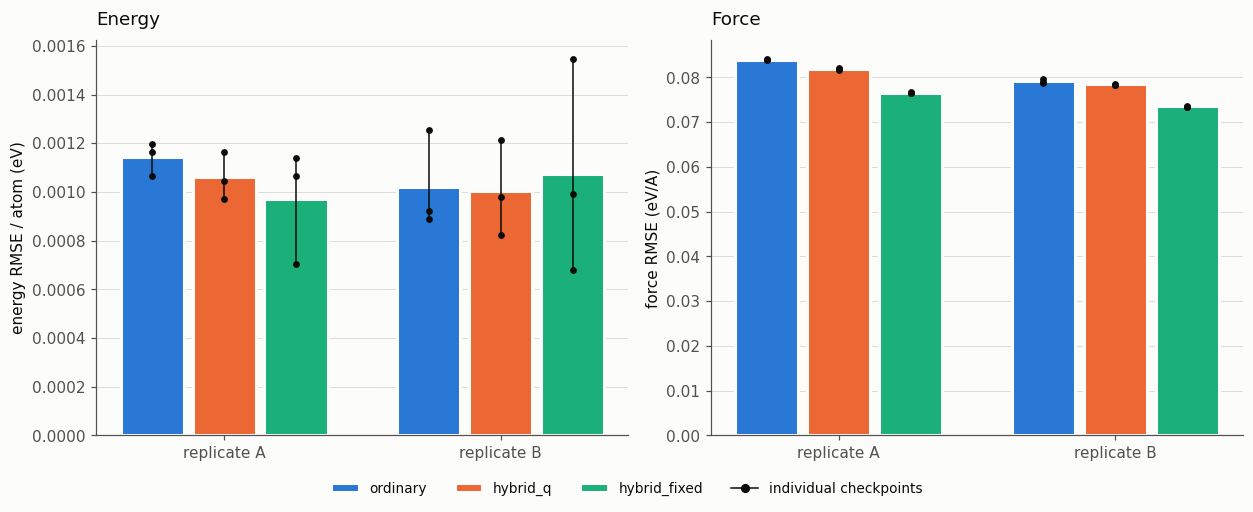

Full-set validation RMSE at the final checkpoint (step 10000)


rmse_e_peratom    rmse_f
model        rep                          
hybrid_fixed A          0.000704  0.076477
             B          0.001547  0.073354
hybrid_q     A          0.000971  0.081749
             B          0.000980  0.078234
ordinary     A          0.001164  0.083804
             B          0.000921  0.078743

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
w = 0.26
panels = [(axes[0], "rmse_e_peratom", "energy RMSE / atom (eV)", "Energy"),
          (axes[1], "rmse_f", "force RMSE (eV/A)", "Force")]
for ax, col, ylab, title in panels:
    for i, m in enumerate(MODELS):
        for j, s in enumerate(SEEDS):
            d = sweep[(sweep.model == m) & (sweep.rep == s) & (sweep.step >= 8000)]
            if not len(d):
                continue
            x = j + (i - 1) * w
            ax.bar(x, d[col].mean(), width=w * 0.88, color=COLOR[m],
                   edgecolor=SURFACE, linewidth=2, label=m if j == 0 else None)
            ax.plot([x, x], [d[col].min(), d[col].max()], color=INK, lw=1, zorder=4)
            ax.scatter([x] * len(d), d[col], s=20, color=INK, zorder=5, linewidth=0)
    ax.set_xticks(range(len(SEEDS)))
    ax.set_xticklabels([f"replicate {s}" for s in SEEDS])
    ax.set_ylabel(ylab)
    ax.set_title(title, loc="left", fontsize=12, pad=10)
    ax.grid(True, axis="y", alpha=0.9)
    ax.set_axisbelow(True)

handles = [mpl.patches.Patch(facecolor=COLOR[m], edgecolor=SURFACE, linewidth=2)
           for m in MODELS]
handles.append(Line2D([], [], color=INK, marker="o", ms=5, lw=1, ls="-"))
fig.legend(handles, MODELS + ["individual checkpoints"],
           loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.015))
fig.tight_layout(rect=(0, 0.045, 1, 1))
plt.show()

if len(sweep):
    last = sweep[sweep.step == 10000].copy()
    print("Full-set validation RMSE at the final checkpoint (step 10000)")
    display(last.pivot_table(index=["model", "rep"],
                             values=["rmse_e_peratom", "rmse_f"]).round(8))

## Inside the LES term

The LES library logs its own state every 100 steps: the per-element latent charges it produces, the norm of the charge-prediction network, and the long-range energy.
This is where the two LES arms turn out to differ most.

`hybrid_fixed` holds physically sensible charges that drift only slightly (H to about +0.61, O to about -1.07), while `hybrid_q` learns charges that collapse toward zero (H about +0.11, O about -0.18).
`hybrid_q`'s long-range energy stays roughly 30x smaller in magnitude for the same reason.
That is consistent with the accuracy result: a long-range channel that carries almost no charge cannot do much for the fit.

Both arms' charge networks do converge: over the last 20 logs the weight norm moves by less than 3 parts in 10^5, and the same is true of the charge spread.
So the late energy oscillation is not LES drift; it is the short-range fitting net.
`E_LR` itself is logged on whichever frame that step happened to see, so it carries per-frame variation on top of a slow drift - read the plateau, not the point-to-point wiggle.

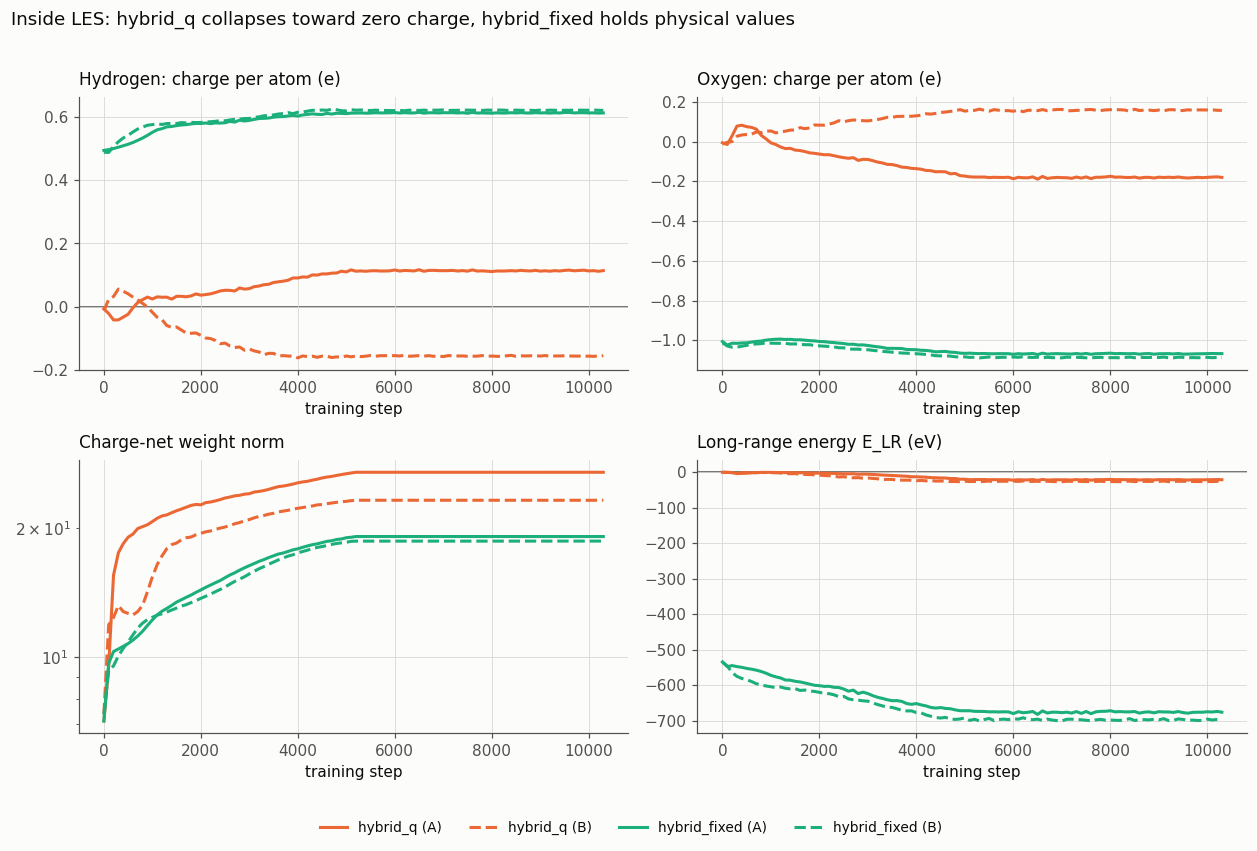

In [7]:
def read_les(model, seed):
    t = tag_of(model, seed)
    rows, cur = [], None
    for line in (EXT / f"run_{t}" / "les.log").open():
        m = re.search(r"Training steps :(\d+)", line)
        if m:
            if cur:
                rows.append(cur)
            cur = {"step": int(m.group(1)), "wnorm": 0.0}
            continue
        if cur is None:
            continue
        m = re.search(r"latent_charges mean: ([\-\d.eE+]+), std: ([\-\d.eE+]+)", line)
        if m:
            cur["q_mean"], cur["q_std"] = float(m.group(1)), float(m.group(2))
        # per-element lines: "<atomic_number> tensor([<mean>]) tensor([<std>])"
        m = re.search(r"les\.les:(\d+)\ttensor\(\[([\-\d.eE+]+)\]", line)
        if m:
            cur[f"q_{m.group(1)}"] = float(m.group(2))
        m = re.search(r"E_lr = ([\-\d.eE+]+)", line)
        if m:
            cur["E_lr"] = float(m.group(1))
        m = re.search(r"\|w\|=([\-\d.eE+]+)", line)
        if m:
            cur["wnorm"] += float(m.group(1))
    if cur:
        rows.append(cur)
    return pd.DataFrame(rows)


les = {(m, s): read_les(m, s) for m in ["hybrid_q", "hybrid_fixed"] for s in SEEDS}

LES_ARMS = [("hybrid_q", s) for s in SEEDS] + [("hybrid_fixed", s) for s in SEEDS]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6))
ax_h, ax_o, ax_w, ax_e = axes.ravel()
for arm in LES_ARMS:
    m, s = arm
    d = les[arm]
    lbl = f"{m} ({s})"
    ax_h.plot(d.step, d.get("q_1"), color=COLOR[m], ls=LS[s], lw=2, label=lbl)
    ax_o.plot(d.step, d.get("q_8"), color=COLOR[m], ls=LS[s], lw=2)
    ax_w.plot(d.step, d.wnorm, color=COLOR[m], ls=LS[s], lw=2)
    ax_e.plot(d.step, d.E_lr, color=COLOR[m], ls=LS[s], lw=2)
ax_h.axhline(0, color=INK2, lw=1, zorder=0)
ax_h.set_title("Hydrogen: charge per atom (e)", loc="left", fontsize=11, pad=8)
ax_o.set_title("Oxygen: charge per atom (e)", loc="left", fontsize=11, pad=8)
ax_w.set_title("Charge-net weight norm", loc="left", fontsize=11, pad=8)
ax_e.set_title("Long-range energy E_LR (eV)", loc="left", fontsize=11, pad=8)
ax_w.set_yscale("log")
ax_e.axhline(0, color=INK2, lw=1, zorder=0)
for a in axes.ravel():
    a.set_xlabel("training step")
    a.grid(True, alpha=0.9)
    a.set_axisbelow(True)
fig.legend(*ax_h.get_legend_handles_labels(), loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Inside LES: hybrid_q collapses toward zero charge, hybrid_fixed holds physical values",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.show()

## Findings

- Exact, reproducible metric: evaluate a checkpoint over the whole validation set, never a single logged point, and never compare a window of logged points against one checkpoint's exact value.
- Force: `hybrid_fixed` beats `ordinary` in both replicates, by 8.8% in A and 7.1% in B on the mean over checkpoints 8000-10000, and its checkpoint range stays strictly below `ordinary`'s in both. This is the one result that holds up.
- `hybrid_q` also beats `ordinary` on force, but by much less: 2.4% in A and 0.9% in B.
- Energy: no reliable ranking. `hybrid_fixed` is 15.1% better in replicate A but 5.0% worse in replicate B, and its checkpoint range overlaps `ordinary`'s in both replicates.
- `hybrid_q` shows no consistent energy advantage either, and the LES log explains why: its learned charges collapse toward zero (H +0.11, O -0.18 against `hybrid_fixed`'s +0.61 and -1.07), leaving its long-range channel roughly 30x weaker.
- Energy error swings by up to 2.3x between adjacent late checkpoints in every arm, `ordinary` included; force error varies by at most 1.1%. Any energy claim on this dataset needs the checkpoint mean and the spread shown together.
- That swing is the energy zero drifting, not the physics. Decomposing `rmse_e^2 = bias^2 + spread^2`, the spread is flat to under 1% across checkpoints while the bias moves 5x, and regressing one checkpoint's per-frame errors on another's gives slope `0.995` with a residual 15x below the signal. The model's error *pattern* is unchanged; a constant per-frame offset moved. The same offset appears on the 320-frame train split, tracking the validation bias to a constant ~1e-4, so it is the model and not the validation frames. Forces are blind to exactly that offset, which is why they stay smooth.

See `LES_PERFORMANCE.md` for the written summary and `eval_full.py` / `sweep_valid.sh` / `diag_bias.py` for the evaluation harness.

## Delaying the cliff: a convergence probe, not an accuracy comparison

**Read this section as a diagnostic.** The two schedules differ only in `decay_steps`, and neither is a schedule worth shipping: one ends the run at `5.93e-6`, the other at `4.56e-7`, small enough that the final 2500 steps barely move the model. The question is narrow - were the latent charges still learning when the rate collapsed, that is underfitted, or had they genuinely converged? - and it is answered from the charge trajectories and from how much the model can still move, not from which arm scores better. No accuracy conclusion follows, in either direction.

The runs above were trained with `decay_steps: 5000` and `numb_steps: 10000`.
That reads like a smooth decay, but `LearningRateExp` (deepmd 3.1.2, `deepmd/dpmodel/utils/learning_rate.py`) is **piecewise constant, not a ramp**:

    decay_rate = exp( log(stop_lr / start_lr) / (stop_steps / decay_steps) )
    lr(step)   = max( start_lr * decay_rate ** (step // decay_steps), stop_lr )

So `decay_steps` is not a decay rate, it is the **length of the high-learning-rate phase**, and with `start_lr 1e-3`, `stop_lr 3.51e-8`, `stop_steps 10000` the two schedules under comparison are:

| `decay_steps` | full rate `1.0e-3` | then | final 2500 steps |
|---|---|---|---|
| 5000 (all runs above) | steps 0 - 4999 | `5.93e-6` for 5000 - 9999 | at `5.93e-6` |
| 7500 (this probe) | steps 0 - 7499 | `4.56e-7` for 7500 - 9999 | at `4.56e-7` |

That single cliff is what raised the question this section answers: with the learning rate collapsing by a factor of ~169 at half time, the latent charges *might* have been frozen by the schedule rather than by having converged, i.e. underfitted.

The test is to move the cliff later.
Six further runs were trained with `decay_steps: 7500` and nothing else changed: same arms, same two seeds, same network, same data order, same loss.
Delaying the cliff buys 2500 extra steps at the full learning rate, and pays for them with a 13x smaller learning rate over the final 2500 steps.
Those two effects cannot be separated inside this one experiment, so the confound is stated with the findings rather than papered over; it limits what the *metrics* can say, not the charge-trajectory evidence below, which compares the two schedules over a window in which only the rate differs.

The comparison is matched, which was checked rather than assumed: the two `input.yaml` files diff to `decay_steps` alone (plus the output filename), the two schedules produce bit-identical charge-network initial weights, a bit-identical `[HybridLES]` step-1 decomposition, and bit-identical learning-curve rows for as long as the learning rate is shared.
This mattered because the model source *did* change between the two run sets (the long-range virial was added in between), so "same config" was not by itself evidence of "same code".

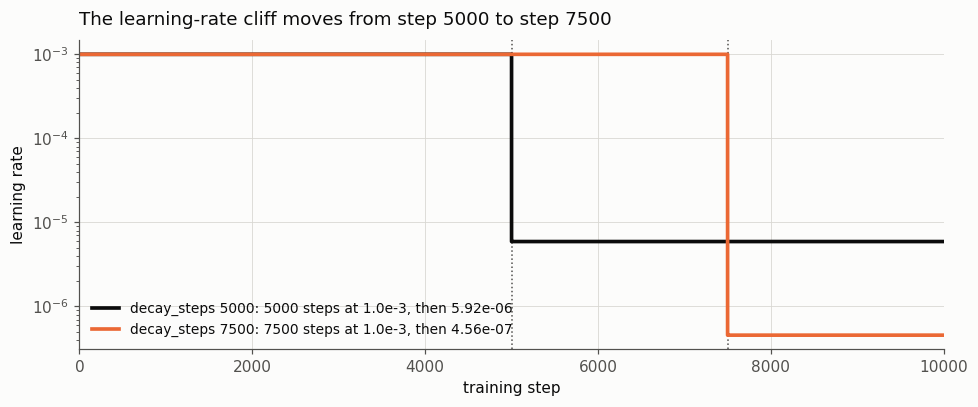

decay_steps 5000: lr(0)=1.000e-03  lr at cliff=5.925e-06  lr(last)=5.925e-06
decay_steps 7500: lr(0)=1.000e-03  lr at cliff=4.560e-07  lr(last)=4.560e-07


In [8]:
from deepmd.common import j_loader
from deepmd.dpmodel.utils.learning_rate import LearningRateExp

DECAYS = [5000, 7500]


def solve_sched(rundir):
    """The exact schedule a run trained with, built from its own input.yaml."""
    j = j_loader(str(EXT / rundir / "input.yaml"))
    lr, n = j["learning_rate"], int(j["training"]["numb_steps"])
    sch = LearningRateExp(start_lr=float(lr["start_lr"]), stop_lr=float(lr["stop_lr"]),
                          decay_steps=int(lr["decay_steps"]), stop_steps=n,
                          decay_rate=lr.get("decay_rate"))
    return sch, n, int(lr["decay_steps"])


scheds = {}
for dec in DECAYS:
    t = tag_of("hybrid_q", "A") + ("" if dec == 5000 else f"_d{dec}")
    scheds[dec] = solve_sched(f"run_{t}")

STEP = np.arange(0, 10000)
fig, ax = plt.subplots(figsize=(9, 3.8))
for dec, col in zip(DECAYS, [INK, COLOR["hybrid_q"]]):
    sch, n, cliff = scheds[dec]
    y = np.array([sch.value(int(s)) for s in STEP])
    ax.step(STEP, y, where="post", lw=2.4, color=col,
            label=f"decay_steps {dec}: {cliff} steps at 1.0e-3, then {y[-1]:.2e}")
    ax.axvline(cliff, color=INK2, lw=1, ls=":", zorder=0)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_xlabel("training step")
ax.set_ylabel("learning rate")
ax.set_title("The learning-rate cliff moves from step 5000 to step 7500",
             loc="left", fontsize=12, pad=10)
ax.grid(True, alpha=0.9)
ax.set_axisbelow(True)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

for dec in DECAYS:
    sch, n, cliff = scheds[dec]
    print(f"decay_steps {dec}: lr(0)={sch.value(0):.3e}  lr at cliff={sch.value(cliff):.3e}"
          f"  lr(last)={sch.value(n - 1):.3e}")


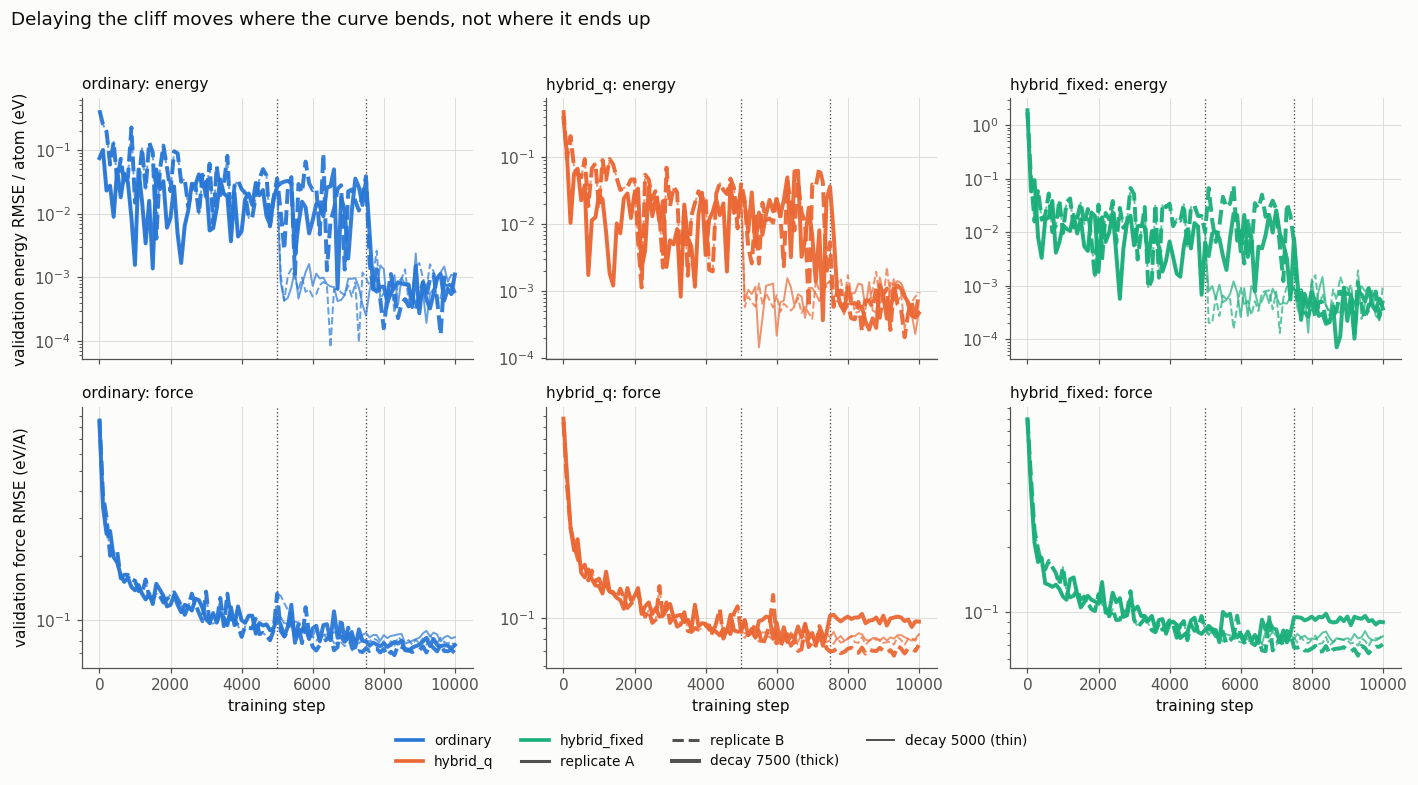

In [9]:
def read_lcurve_decay(model, seed, decay):
    t = tag_of(model, seed) + ("" if decay == 5000 else f"_d{decay}")
    return pd.read_csv(EXT / f"run_{t}" / f"lcurve_{t}.out",
                       sep=r"\s+", skiprows=2, names=LC_COLS)


curves2 = {(m, s, d): read_lcurve_decay(m, s, d)
           for m in MODELS for s in SEEDS for d in DECAYS}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for col, m in enumerate(MODELS):
    for row, (ycol, ylab) in enumerate([("rmse_e_val", "validation energy RMSE / atom (eV)"),
                                        ("rmse_f_val", "validation force RMSE (eV/A)")]):
        ax = axes[row, col]
        for s in SEEDS:
            for d in DECAYS:
                c = curves2[(m, s, d)]
                ax.plot(c.step, c[ycol], color=COLOR[m], ls=LS[s],
                        lw=2.6 if d == 7500 else 1.3,
                        alpha=0.95 if d == 7500 else 0.7)
        for cliff in DECAYS:
            ax.axvline(cliff, color=INK2, lw=0.9, ls=":", zorder=0)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.9)
        ax.set_axisbelow(True)
        ax.set_title(f"{m}: {'energy' if row == 0 else 'force'}",
                     loc="left", fontsize=10, pad=6)
        if row == 1:
            ax.set_xlabel("training step")
        if col == 0:
            ax.set_ylabel(ylab)
fig.legend(handles=(
    [Line2D([], [], color=COLOR[m], lw=2.4, label=m) for m in MODELS]
    + [Line2D([], [], color=INK2, ls=LS[s], lw=2, label=f"replicate {s}") for s in SEEDS]
    + [Line2D([], [], color=INK2, lw=2.6, label="decay 7500 (thick)"),
       Line2D([], [], color=INK2, lw=1.3, label="decay 5000 (thin)")]
), loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Delaying the cliff moves where the curve bends, not where it ends up",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.045, 1, 0.96))
plt.show()


### The cliff freezes the model in place

The diagnostic signature is not the metric average but the metric's *stability*.
Over steps 8000 - 10000, by which point both schedules are past their cliff, the `decay_steps 7500` arms are flat while the `5000` arms are still moving: the energy zero keeps wandering at `5.93e-6` and stops entirely at `4.56e-7`.

That matters for the comparison, because a frozen run is a snapshot of wherever it stood when the rate collapsed.
Whatever difference exists between the two replicates at the cliff therefore survives to the end - there is no low-rate tail left to anneal it away - which is what the right-hand panel below shows.

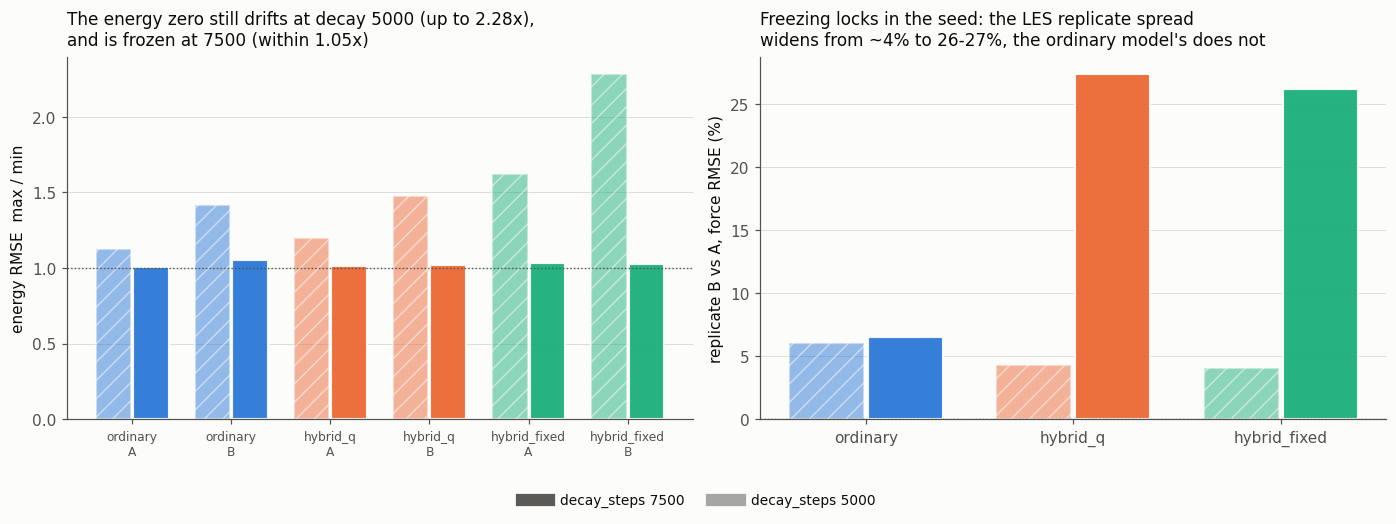

stability over steps 8000-10000:
       model rep  decay  e_ratio  f_drift
hybrid_fixed   A   5000   +1.620   -0.292
hybrid_fixed   A   7500   +1.031   -2.937
hybrid_fixed   B   5000   +2.281   -0.428
hybrid_fixed   B   7500   +1.027   -0.105
    hybrid_q   A   5000   +1.200   -0.409
    hybrid_q   A   7500   +1.011   -3.270
    hybrid_q   B   5000   +1.477   -0.489
    hybrid_q   B   7500   +1.023   -0.094
    ordinary   A   5000   +1.123   -0.394
    ordinary   A   7500   +1.008   -0.247
    ordinary   B   5000   +1.414   -1.045
    ordinary   B   7500   +1.052   -0.153

replicate spread in force RMSE at the final checkpoint, %:
              5000  7500
model                   
hybrid_fixed  +4.1 +26.2
hybrid_q      +4.3 +27.4
ordinary      +6.0  +6.6


In [10]:
def sweep(path, decay):
    d = pd.read_csv(path, sep="\t")
    d["decay"] = decay
    return d


sw = pd.concat([sweep(HERE / "sweep_valid.tsv", 5000),
                sweep(HERE / "sweep_valid_d7500.tsv", 7500)])
# The matched window: the only steps where both schedules are past their cliff.
win = sw[sw.step.between(8000, 10000)].sort_values(["run", "decay", "step"])
runs = [(m, s) for m in MODELS for s in SEEDS]

stab = win.groupby(["run", "model", "rep", "decay"]).agg(
    e_lo=("rmse_e_peratom", "min"), e_hi=("rmse_e_peratom", "max"),
    f_first=("rmse_f", "first"), f_last=("rmse_f", "last")).reset_index()
stab["e_ratio"] = stab.e_hi / stab.e_lo            # energy-zero drift
stab["f_drift"] = 100 * (stab.f_last / stab.f_first - 1)

# Replicate B's final-checkpoint force RMSE relative to A, as a magnitude: how
# far apart the two seeds land. This is what widens when the run freezes.
last = win[win.step == 10000].pivot_table(
    index="model", columns=["decay", "rep"], values="rmse_f")
spread = pd.DataFrame({d: (100 * (last[d]["B"] / last[d]["A"] - 1)).abs()
                       for d in DECAYS})

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
ax = axes[0]
x = np.arange(len(runs))
for k, dec in enumerate(DECAYS):
    sel = [stab[(stab.model == m) & (stab.rep == s)
                & (stab.decay == dec)].iloc[0] for m, s in runs]
    ax.bar(x + (k - 0.5) * 0.38, [r.e_ratio for r in sel], width=0.36,
           color=[COLOR[m] for m, s in runs],
           alpha=0.95 if dec == 7500 else 0.5,
           hatch=None if dec == 7500 else "//",
           edgecolor=SURFACE, linewidth=1.4)
ax.axhline(1.0, color=INK2, lw=0.9, ls=":")
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n{s}" for m, s in runs], fontsize=8)
ax.set_ylabel("energy RMSE  max / min")
ax.set_title("The energy zero still drifts at decay 5000 (up to 2.28x),\n"
             "and is frozen at 7500 (within 1.05x)",
             loc="left", fontsize=11, pad=8)
ax.grid(True, axis="y", alpha=0.9)
ax.set_axisbelow(True)

ax = axes[1]
x = np.arange(len(MODELS))
for k, dec in enumerate(DECAYS):
    ax.bar(x + (k - 0.5) * 0.38, [spread.loc[m, dec] for m in MODELS], width=0.36,
           color=[COLOR[m] for m in MODELS],
           alpha=0.95 if dec == 7500 else 0.5,
           hatch=None if dec == 7500 else "//",
           edgecolor=SURFACE, linewidth=1.4)
ax.axhline(0.0, color=INK2, lw=0.9, ls=":")
ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel("replicate B vs A, force RMSE (%)")
ax.set_title("Freezing locks in the seed: the LES replicate spread\n"
             "widens from ~4% to 26-27%, the ordinary model's does not",
             loc="left", fontsize=11, pad=8)
ax.grid(True, axis="y", alpha=0.9)
ax.set_axisbelow(True)

fig.legend(handles=[Line2D([], [], color=INK2, lw=8, alpha=0.95,
                           label="decay_steps 7500"),
                    Line2D([], [], color=INK2, lw=8, alpha=0.5,
                           label="decay_steps 5000")],
           loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

print("stability over steps 8000-10000:")
print(stab[["model", "rep", "decay", "e_ratio", "f_drift"]].to_string(
    index=False, float_format=lambda v: f"{v:+.3f}"))
print()
print("replicate spread in force RMSE at the final checkpoint, %:")
print(spread.to_string(float_format=lambda v: f"{v:+.1f}"))

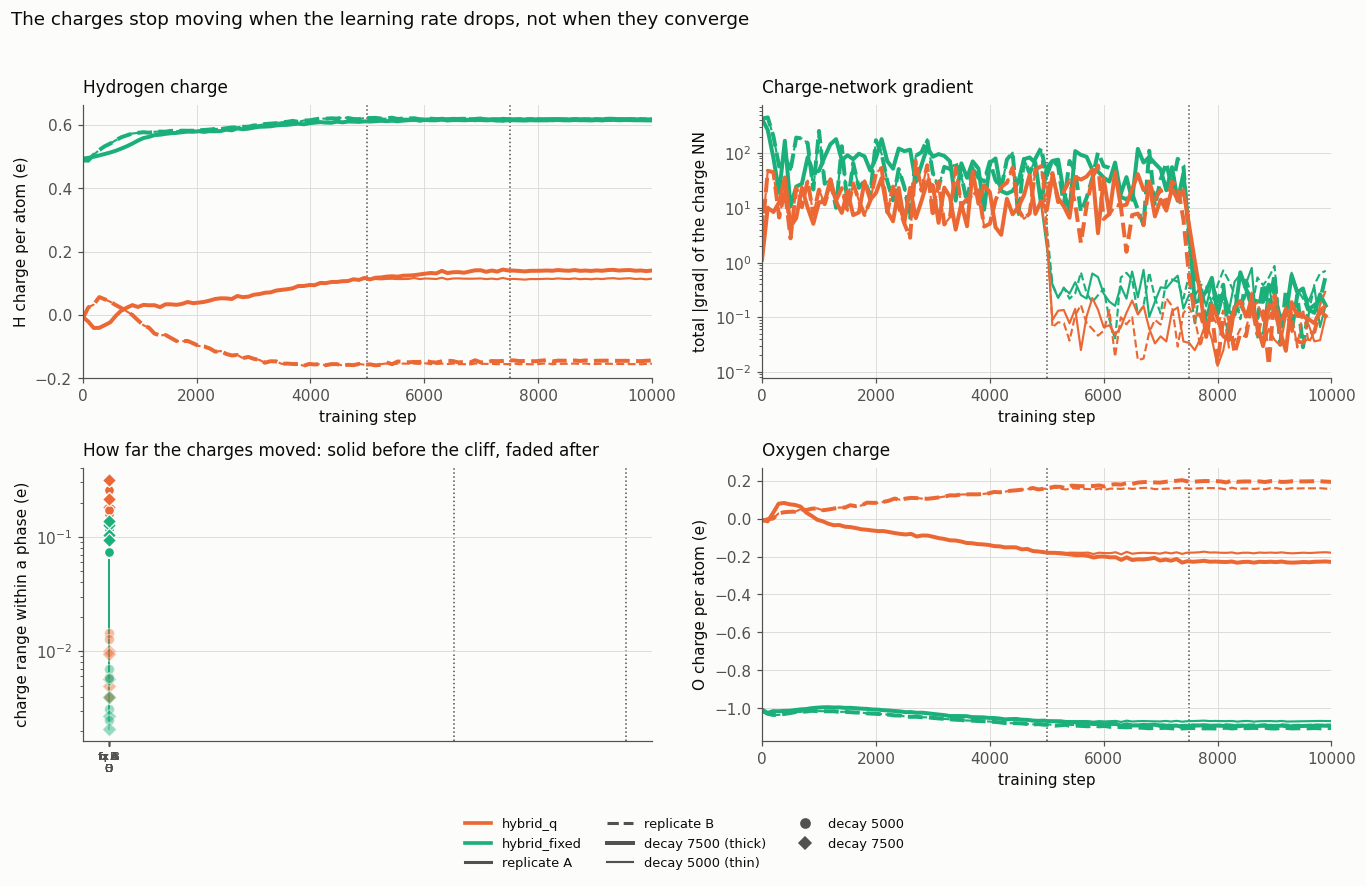

run_hybrid_q_sA            cliff 5000  |grad| median 1.265e+01 -> 7.961e-02   q_H -0.0064 -> +0.1144   q_O -0.0059 -> -0.1799
run_hybrid_q_sB            cliff 5000  |grad| median 1.414e+01 -> 8.215e-02   q_H -0.0121 -> -0.1543   q_O -0.0125 -> +0.1571
run_hybrid_fixed_sA        cliff 5000  |grad| median 7.280e+01 -> 2.741e-01   q_H +0.4936 -> +0.6118   q_O -1.0059 -> -1.0669
run_hybrid_fixed_sB        cliff 5000  |grad| median 5.374e+01 -> 3.408e-01   q_H +0.4879 -> +0.6198   q_O -1.0125 -> -1.0863
run_hybrid_q_sA_d7500      cliff 7500  |grad| median 1.332e+01 -> 1.050e-01   q_H -0.0064 -> +0.1401   q_O -0.0059 -> -0.2284
run_hybrid_q_sB_d7500      cliff 7500  |grad| median 1.367e+01 -> 6.688e-02   q_H -0.0121 -> -0.1442   q_O -0.0125 -> +0.1935
run_hybrid_fixed_sA_d7500  cliff 7500  |grad| median 6.641e+01 -> 2.132e-01   q_H +0.4936 -> +0.6178   q_O -1.0059 -> -1.0918
run_hybrid_fixed_sB_d7500  cliff 7500  |grad| median 4.934e+01 -> 2.025e-01   q_H +0.4879 -> +0.6151   q_O -1.0125 -> 

In [11]:
q_tab = pd.read_csv(HERE / "lrphase_q.tsv", sep="\t")
g_tab = pd.read_csv(HERE / "lrphase_grad.tsv", sep="\t")
g_tab["g_tot"] = g_tab.groupby(["run", "step"]).grad.transform(
    lambda s: np.sqrt((s ** 2).sum()))

ARM_NAMES = ["run_hybrid_q_sA", "run_hybrid_q_sB",
             "run_hybrid_fixed_sA", "run_hybrid_fixed_sB"]
ARMS8 = ARM_NAMES + [a + "_d7500" for a in ARM_NAMES]


def short(run):
    return f"{'q' if 'hybrid_q' in run else 'fx'} {run.split('_s')[1][0]} d{'7500' if run.endswith('7500') else '5000'}"


def draw(run, col, ax):
    d = q_tab[q_tab.run == run]
    ax.plot(d.step, d[col], color=COLOR[d.model.iloc[0]], ls=LS[d.rep.iloc[0]],
            lw=2.6 if d.decay.iloc[0] == 7500 else 1.4, label=short(run))


fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.8))
ax_h, ax_d, ax_e, ax_o = (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1])

for a in ARMS8:
    draw(a, "q_1", ax_h)
    draw(a, "q_8", ax_o)
for run, d in g_tab.groupby("run"):
    t = d.drop_duplicates("step")
    ax_d.plot(t.step, t.g_tot, color=COLOR[t.model.iloc[0]], ls=LS[t.rep.iloc[0]],
              lw=2.6 if t.decay.iloc[0] == 7500 else 1.4)
ax_d.set_yscale("log")

# How far each charge moved while the rate was high (solid) and afterwards
# (faded). Each phase is cut at that run's own cliff, so "pre-cliff" is 5000
# steps for one schedule and 7500 for the other.
for i, a in enumerate(ARM_NAMES):
    d = q_tab[q_tab.run == a]
    for j, col in enumerate(["q_1", "q_8"]):
        x = i * 2 + j
        for k, dec in enumerate(DECAYS):
            dd = q_tab[q_tab.run == (a if dec == 5000 else a + "_d7500")]
            pre, post = dd[dd.step <= dec][col], dd[dd.step > dec][col]
            xs = x + (k - 0.5) * 0.30
            ax_e.plot([xs, xs], [pre.max() - pre.min(), post.max() - post.min()],
                      color=COLOR[d.model.iloc[0]], lw=1.2, alpha=0.5, zorder=1)
            ax_e.scatter([xs], [pre.max() - pre.min()], s=42, zorder=3,
                         color=COLOR[d.model.iloc[0]], marker="o" if dec == 5000 else "D",
                         edgecolor=SURFACE, linewidth=0.8)
            ax_e.scatter([xs], [post.max() - post.min()], s=42, zorder=3,
                         color=COLOR[d.model.iloc[0]], marker="o" if dec == 5000 else "D",
                         edgecolor=SURFACE, linewidth=0.8, alpha=0.45)
ax_e.set_yscale("log")
ax_e.set_xticks([i * 2 + j for i in range(4) for j in range(2)])
ax_e.set_xticklabels([f"{' '.join(short(a).split()[:2])}\n{el}" for a in ARM_NAMES
                      for el in ("H", "O")], fontsize=7)

for a in (ax_h, ax_d, ax_e, ax_o):
    for cliff in DECAYS:
        a.axvline(cliff, color=INK2, lw=1, ls=":", zorder=0)
for a in (ax_h, ax_d, ax_o):
    a.set_xlim(0, 10000)
for a, lab in [(ax_h, "H charge per atom (e)"), (ax_o, "O charge per atom (e)"),
               (ax_d, "total |grad| of the charge NN"),
               (ax_e, "charge range within a phase (e)")]:
    a.set_ylabel(lab)
for a, lab in [(ax_h, "Hydrogen charge"), (ax_o, "Oxygen charge"),
               (ax_d, "Charge-network gradient"),
               (ax_e, "How far the charges moved: solid before the cliff, faded after")]:
    a.set_title(lab, loc="left", fontsize=11, pad=8)
for a in (ax_h, ax_d, ax_o):
    a.set_xlabel("training step")
    a.grid(True, alpha=0.9)
    a.set_axisbelow(True)
ax_e.grid(True, axis="y", alpha=0.9)
ax_e.set_axisbelow(True)
fig.legend(handles=(
    [Line2D([], [], color=COLOR[m], lw=2.4, label=m) for m in ("hybrid_q", "hybrid_fixed")]
    + [Line2D([], [], color=INK2, ls=LS[s], lw=2, label=f"replicate {s}") for s in SEEDS]
    + [Line2D([], [], color=INK2, lw=2.6, label="decay 7500 (thick)"),
       Line2D([], [], color=INK2, lw=1.4, label="decay 5000 (thin)"),
       Line2D([], [], color=INK2, ls="none", marker="o", ms=6, label="decay 5000"),
       Line2D([], [], color=INK2, ls="none", marker="D", ms=6, label="decay 7500")]
), loc="lower center", ncol=3, fontsize=8.5, bbox_to_anchor=(0.5, -0.035))
fig.suptitle("The charges stop moving when the learning rate drops, not when they converge",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.055, 1, 0.96))
plt.show()

for a in ARMS8:
    d = q_tab[q_tab.run == a]
    dec = int(d.decay.iloc[0])
    tot = g_tab[g_tab.run == a].drop_duplicates("step")
    pre, post = tot[tot.step <= dec], tot[tot.step > dec]
    print(f"{a:26s} cliff {dec}  |grad| median {pre.g_tot.median():.3e} -> "
          f"{post.g_tot.median():.3e}   q_H {d.q_1.iloc[0]:+.4f} -> {d.q_1.iloc[-1]:+.4f}"
          f"   q_O {d.q_8.iloc[0]:+.4f} -> {d.q_8.iloc[-1]:+.4f}")

# The cleanest comparison in the whole section: one window, two schedules. Over
# steps 5001-7500 the decay-5000 arm is already below its cliff and the
# decay-7500 arm is still at the full rate, and the two ran the identical
# trajectory up to step 5000.
print()
print("Same window, two schedules: steps 5001-7500")
print(f"{'arm':7s} {'el':3s} {'d5000 |grad|':>13s} {'d7500 |grad|':>13s}"
      f" {'d5000 drift':>12s} {'d7500 drift':>12s}")
for a in ARM_NAMES:
    for el in ("q_1", "q_8"):
        cell = []
        for suffix in ("", "_d7500"):
            tot = g_tab[g_tab.run == a + suffix].drop_duplicates("step")
            w = tot[tot.step.between(5001, 7500)]
            qq = q_tab[q_tab.run == a + suffix]
            qq = qq[qq.step.between(5001, 7500)][el]
            cell.append((w.g_tot.median(), qq.max() - qq.min()))
        print(f"{'q' if 'hybrid_q' in a else 'fx'} {a.split('_s')[1][0]:3s} {el:3s} "
              f"{cell[0][0]:13.3e} {cell[1][0]:13.3e} "
              f"{cell[0][1]:12.4f} {cell[1][1]:12.4f}")


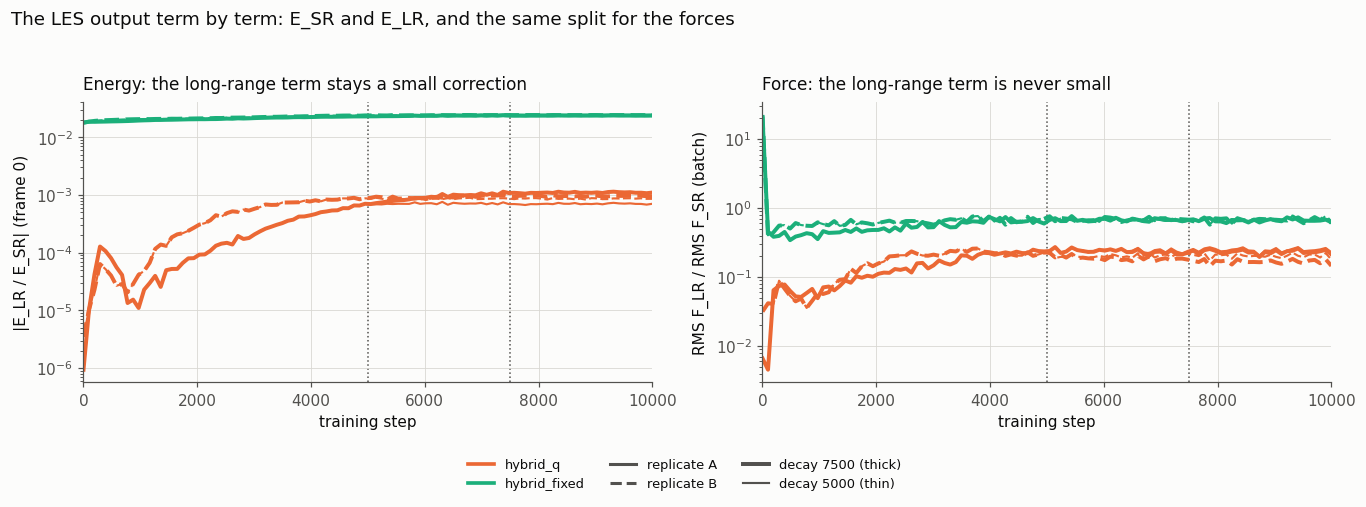

                                       E_SR        E_LR        r_e   RMS_F_SR   RMS_F_LR        r_f
run                       decay                                                                    
run_hybrid_fixed_sA       5000  -2.9268e+04 -6.7559e+02 2.3083e-02 7.2023e-01 4.8215e-01 6.7048e-01
run_hybrid_fixed_sA_d7500 7500  -2.9244e+04 -6.9988e+02 2.3933e-02 7.5831e-01 5.0323e-01 6.6457e-01
run_hybrid_fixed_sB       5000  -2.9247e+04 -6.9706e+02 2.3834e-02 7.8703e-01 5.3888e-01 6.8654e-01
run_hybrid_fixed_sB_d7500 7500  -2.9237e+04 -7.0690e+02 2.4179e-02 7.6489e-01 5.1976e-01 6.8111e-01
run_hybrid_q_sA           5000  -2.9922e+04 -2.1123e+01 7.0593e-04 8.3811e-01 2.0558e-01 2.4629e-01
run_hybrid_q_sA_d7500     7500  -2.9911e+04 -3.3026e+01 1.1042e-03 8.4520e-01 1.9499e-01 2.3157e-01
run_hybrid_q_sB           5000  -2.9918e+04 -2.5791e+01 8.6206e-04 8.0998e-01 1.6477e-01 2.0401e-01
run_hybrid_q_sB_d7500     7500  -2.9915e+04 -2.8683e+01 9.5881e-04 8.0336e-01 1.3426e-01 1.6756e-01


In [12]:
s_tab = pd.read_csv(HERE / "lrphase_srlr.tsv", sep="\t")

# The log's own ratio columns are printed to 4 decimals, so anything below
# 5e-5 is literally logged as 0.0000 and would vanish on a log axis. Recomputed
# from the two energies, which are logged to 6 significant digits. E_SR and E_LR
# are frame 0 of the batch, so r_e is that frame's ratio.
s_tab["r_e"] = (s_tab.E_LR / s_tab.E_SR).abs()
s_tab["r_f"] = s_tab.RMS_F_LR / s_tab.RMS_F_SR

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for run, d in s_tab.groupby("run"):
    lw = 2.6 if d.decay.iloc[0] == 7500 else 1.4
    axes[0].plot(d.step, d.r_e, color=COLOR[d.model.iloc[0]],
                 ls=LS[d.rep.iloc[0]], lw=lw)
    axes[1].plot(d.step, d.r_f, color=COLOR[d.model.iloc[0]],
                 ls=LS[d.rep.iloc[0]], lw=lw)
for a in axes:
    for cliff in DECAYS:
        a.axvline(cliff, color=INK2, lw=1, ls=":", zorder=0)
    a.set_yscale("log")
    a.set_xlim(0, 10000)
    a.set_xlabel("training step")
    a.grid(True, alpha=0.9)
    a.set_axisbelow(True)
axes[0].set_ylabel("|E_LR / E_SR| (frame 0)")
axes[1].set_ylabel("RMS F_LR / RMS F_SR (batch)")
axes[0].set_title("Energy: the long-range term stays a small correction",
                  loc="left", fontsize=11, pad=8)
axes[1].set_title("Force: the long-range term is never small", loc="left", fontsize=11, pad=8)
fig.legend(handles=(
    [Line2D([], [], color=COLOR[m], lw=2.4, label=m) for m in ("hybrid_q", "hybrid_fixed")]
    + [Line2D([], [], color=INK2, ls=LS[s], lw=2, label=f"replicate {s}") for s in SEEDS]
    + [Line2D([], [], color=INK2, lw=2.6, label="decay 7500 (thick)"),
       Line2D([], [], color=INK2, lw=1.4, label="decay 5000 (thin)")]
), loc="lower center", ncol=3, fontsize=8.5, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("The LES output term by term: E_SR and E_LR, and the same split for the forces",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()

late = s_tab[s_tab.step >= 8000]
print(late.groupby(["run", "decay"])[["E_SR", "E_LR", "r_e",
                                      "RMS_F_SR", "RMS_F_LR", "r_f"]]
      .mean().to_string(float_format=lambda v: f"{v:.4e}"))


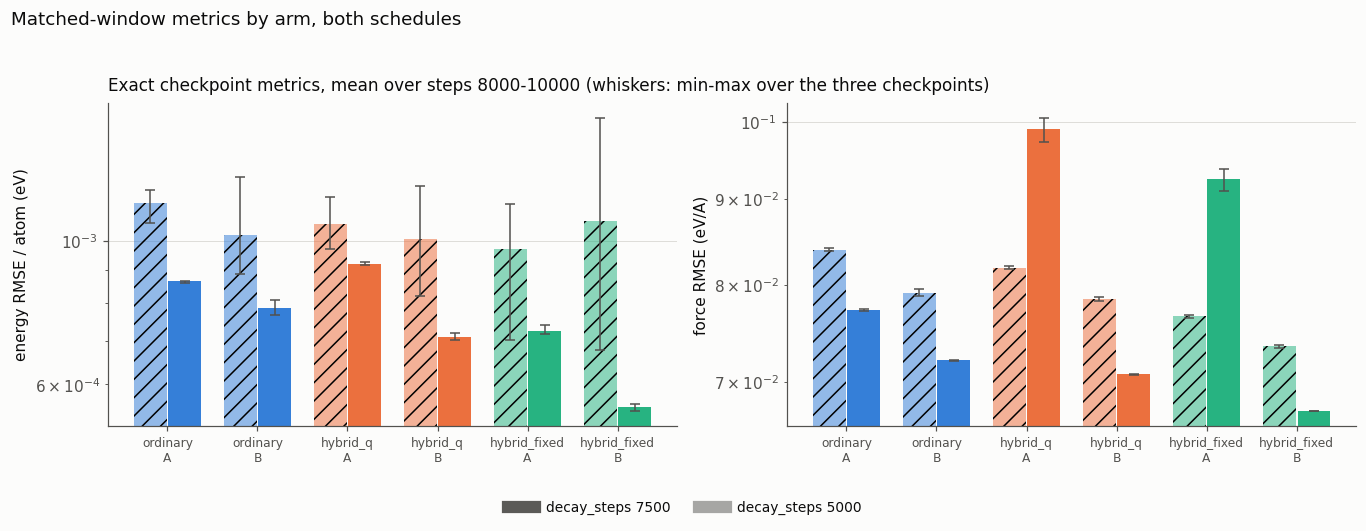

window mean per replicate, steps 8000-10000:
                          e                     f           
decay                  5000       7500       5000       7500
model        rep                                            
hybrid_fixed A   9.6939e-04 7.2562e-04 7.6590e-02 9.2516e-02
             B   1.0720e-03 5.5469e-04 7.3504e-02 6.7253e-02
hybrid_q     A   1.0602e-03 9.2050e-04 8.1909e-02 9.9097e-02
             B   1.0057e-03 7.1018e-04 7.8412e-02 7.0733e-02
ordinary     A   1.1422e-03 8.6505e-04 8.3962e-02 7.7239e-02
             B   1.0213e-03 7.8699e-04 7.9125e-02 7.2137e-02

arm mean over the window, then the change between the schedules, %:
              d_e_%  d_f_%
model                     
hybrid_fixed  -37.3   +6.4
hybrid_q      -21.1   +5.9
ordinary      -23.6   -8.4

the same change taken at the single final checkpoint instead, %:
                  d_e_%  d_f_%
model        rep              
hybrid_fixed A    +2.11 +19.04
             B   -63.87  -8.37
hybrid_q    

In [13]:
# Mean over the matched window 8000-10000, not over the single final
# checkpoint: for decay_steps 5000 the energy series is still drifting (up to
# 2.28x across the window), so one checkpoint is an arbitrary phase of it, and
# for 7500 the final checkpoint is a frozen snapshot rather than a converged
# value. Only in this window are both schedules past their cliff.
mwin = sw[sw.step.between(8000, 10000)]
agg = mwin.groupby(["model", "rep", "decay"]).agg(
    e=("rmse_e_peratom", "mean"), e_lo=("rmse_e_peratom", "min"),
    e_hi=("rmse_e_peratom", "max"), f=("rmse_f", "mean"),
    f_lo=("rmse_f", "min"), f_hi=("rmse_f", "max")).reset_index()

ARMS6 = [(m, s) for m in MODELS for s in SEEDS]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (col, lo, hi, lab) in zip(axes, [("e", "e_lo", "e_hi", "energy RMSE / atom (eV)"),
                                        ("f", "f_lo", "f_hi", "force RMSE (eV/A)")]):
    x = np.arange(len(ARMS6))
    for k, dec in enumerate(DECAYS):
        sel = [agg[(agg.model == m) & (agg.rep == s) & (agg.decay == dec)].iloc[0]
               for m, s in ARMS6]
        ax.bar(x + (k - 0.5) * 0.38, [r[col] for r in sel], width=0.36,
               color=[COLOR[m] for m, s in ARMS6], alpha=0.95 if dec == 7500 else 0.5,
               hatch=None if dec == 7500 else "//",
               yerr=[[r[col] - r[lo] for r in sel], [r[hi] - r[col] for r in sel]],
               error_kw=dict(lw=1, capsize=3, ecolor=INK2))
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m}\n{s}" for m, s in ARMS6], fontsize=8)
    ax.set_ylabel(lab)
    ax.grid(True, axis="y", alpha=0.9)
    ax.set_axisbelow(True)
axes[0].set_title("Exact checkpoint metrics, mean over steps 8000-10000 "
                  "(whiskers: min-max over the three checkpoints)",
                  loc="left", fontsize=11, pad=8)
fig.legend(handles=[
    Line2D([], [], color=INK2, lw=8, alpha=0.95, label="decay_steps 7500"),
    Line2D([], [], color=INK2, lw=8, alpha=0.5, label="decay_steps 5000"),
], loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Matched-window metrics by arm, both schedules",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

piv = agg.pivot_table(index=["model", "rep"], columns="decay", values=["e", "f"])
byarm = agg.groupby(["model", "decay"])[["e", "f"]].mean().unstack("decay")
# Ratio of the arm means, not the mean of the per-replicate ratios: with a 26%
# replicate spread the two differ (hybrid_fixed: -37.3% against -36.7%), and the
# ratio of means is the one that describes the arm.
arm_delta = pd.DataFrame({
    "d_e_%": 100 * (byarm[("e", 7500)] / byarm[("e", 5000)] - 1),
    "d_f_%": 100 * (byarm[("f", 7500)] / byarm[("f", 5000)] - 1),
})
# The same change taken at the single final checkpoint instead, which is what the
# earlier revision of this analysis did. It is invalid twice over: for decay 5000
# the energy series is still drifting, so one checkpoint is an arbitrary phase of
# it, and for 7500 it is a frozen snapshot rather than a converged value.
# hybrid_fixed B's final value is that run's own window maximum, and is most of
# its apparent -63.9%.
# `win` is the raw sweep, so the values here are the sweep's own column names.
fin = win[win.step == 10000].pivot_table(
    index=["model", "rep"], columns="decay",
    values=["rmse_e_peratom", "rmse_f"])
fin_delta = pd.DataFrame({
    "d_e_%": 100 * (fin[("rmse_e_peratom", 7500)] / fin[("rmse_e_peratom", 5000)] - 1),
    "d_f_%": 100 * (fin[("rmse_f", 7500)] / fin[("rmse_f", 5000)] - 1),
})
print("window mean per replicate, steps 8000-10000:")
print(piv.to_string(float_format=lambda v: f"{v:.4e}"))
print()
print("arm mean over the window, then the change between the schedules, %:")
print(arm_delta.to_string(float_format=lambda v: f"{v:+.1f}"))
print()
print("the same change taken at the single final checkpoint instead, %:")
print(fin_delta.to_string(float_format=lambda v: f"{v:+.2f}"))
print()
# The replicate, not the arm, decides the sign: both hybrid arms' replicate A
# grows about 20% and both B's fall 8-10%, so the arm-level force change
# (+6.4% and +5.9%) is a two-sample mean of a quantity whose spread is 26%.
print("replicate spread in force RMSE at the final checkpoint, % (|B/A - 1|):")
print(spread.to_string(float_format=lambda v: f"{v:+.1f}"))